In [1]:
# %%
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

import os
import sys

sys.path.insert(0, os.path.abspath("../.."))

from vempc.core.mpc import MPCProblem
from vempc.core import mpc as mpc_utils
from vempc.core.constraints import ConstraintPenalty
from vempc.core.variational import VariationalMPC

from vempc.examples import double_integrator as di
from vempc.solvers import qpMPC
from vempc.solvers import sampling

np.random.seed(9)

Double Integrator from Bemporad's textbook

In [2]:
A, B     = di.A, di.B
Q, R, Qf = di.Q, di.R, di.Qf
Gx, hx   = di.Gx, di.hx
Gu, hu   = di.Gu, di.hu

n, m_in  = A.shape[0], B.shape[1]
N        = 3
T_steps  = 50
x0       = np.array([1.2, 0.3])

# Build condensed MPC
mpc = MPCProblem(A, B, Q, R, Qf, N)
G, h_of_x0 = mpc.build_constraint_matrices(Gx, hx, Gu, hu)
penalty    = ConstraintPenalty(G, h_of_x0)
S, H, Nm   = mpc.S, mpc.H, mpc.Nm

print(f"n={n}, m={m_in}, N={N}, Nm={Nm}, p={G.shape[0]}")

n=2, m=1, N=3, Nm=3, p=18


In [3]:
prob_qp, U_var, q_par, h_par = qpMPC.make_standard_qp_solver(H, G)

def ctrl_standard(x, U_warm):
    u, Useq = qpMPC.solve_standard_mpc(
        x, S=S, h_of_x0=h_of_x0, m_in=m_in,
        prob=prob_qp, U_var=U_var, q_par=q_par, h_par=h_par,
        warm_start_U=U_warm,
    )
    return u, Useq

xs_std, us_std, _, t_std = mpc_utils.simulate(
    "Standard MPC", x0, ctrl_standard, A=A, B=B, T_steps=T_steps,
    noise_std=0.02, seed=9
)

cost_std = mpc_utils.trajectory_cost(xs_std, us_std, Q=Q, R=R, Qf=Qf)
viol_std = mpc_utils.max_constraint_violation(xs_std, us_std, Gx=Gx, hx=hx, Gu=Gu, hu=hu)
print(f"\nStandard MPC\n *  cost={cost_std:.4f}\n *  viol_u={viol_std[1]:.2e}\n *  time={t_std:.3f}s")


Standard MPC
 *  cost=11.0314
 *  viol_u=0.00e+00
 *  time=0.053s


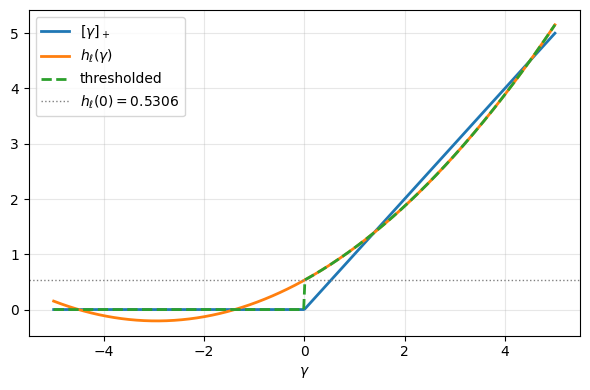

In [4]:

cheb_order = 3
cheb_bound = 5.0
eta_surrogate = 100.0

surrogate_solver = qpMPC.make_surrogate_qp_solver(
    H, G, cheb_order=cheb_order, cheb_bound=cheb_bound, eta=eta_surrogate
)

# Visualize polynomial approximation
z = np.linspace(-cheb_bound, cheb_bound, 400)
p_z = qpMPC.eval_relu_poly(z, surrogate_solver["coeffs"], cheb_bound)
h_l_0 = float(qpMPC.eval_relu_poly(0.0, surrogate_solver["coeffs"], cheb_bound))
p_thresh_viz = np.where(p_z < h_l_0, 0.0, p_z)

plt.figure(figsize=(6, 4))
plt.plot(z, np.maximum(0, z), label=r'$[\gamma]_+$', linewidth=2.0)
plt.plot(z, p_z, label=r'$h_\ell(\gamma)$', linewidth=2.0)
plt.plot(z, p_thresh_viz, '--', label=r'thresholded', linewidth=2.0)
plt.axhline(h_l_0, color='gray', linestyle=':', linewidth=1.0,
            label=rf'$h_\ell(0)={h_l_0:.4f}$')
plt.xlabel(r'$\gamma$')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:

def ctrl_surrogate(x, U_warm):
    u, Useq = qpMPC.solve_surrogate_mpc(
        x, S=S, h_of_x0=h_of_x0, m_in=m_in,
        solver=surrogate_solver, warm_start_U=U_warm,
    )
    return u, Useq

xs_sur, us_sur, _, t_sur = mpc_utils.simulate(
    "Surrogate MPC", x0, ctrl_surrogate, A=A, B=B, T_steps=T_steps,
    noise_std=0.02, seed=9
)

cost_sur = mpc_utils.trajectory_cost(xs_sur, us_sur, Q=Q, R=R, Qf=Qf)
viol_sur = mpc_utils.max_constraint_violation(xs_sur, us_sur, Gx=Gx, hx=hx, Gu=Gu, hu=hu)
print(f"\nSurrogate MPC\n *  cost={cost_sur:.4f}\n *  viol_u={viol_sur[1]:.2e}\n *  time={t_sur:.3f}s")


Surrogate MPC
 *  cost=13.1208
 *  viol_u=3.08e-01
 *  time=0.068s


We can try to set $\Sigma_U$ as a design factor, and then resolve $\Sigma_0$.

In [6]:
import cvxpy as cp

def design_sigma_u_sdp(x0, lam, H, S, G, h_of_x0, eps=1e-6):
    Nm    = H.shape[0]
    H_inv = np.linalg.inv(H)
    SU    = cp.Variable((Nm, Nm), symmetric=True)

    ST_x0 = S.T @ x0
    m_U   = -(1.0 / lam) * (SU @ ST_x0)

    prob = cp.Problem(
        cp.Maximize(cp.log_det(SU)),
        [
            G @ m_U <= h_of_x0(x0),     # mean inside F(x0)
            lam * H_inv - SU >> 0,      # existence of Sigma_0
            SU >> eps * np.eye(Nm),     # PD
        ]
    )
    prob.solve(solver=cp.CLARABEL, verbose=False)

    if prob.status not in ["optimal", "optimal_inaccurate"]:
        return None, None, np.inf

    SU_opt = SU.value
    m_U_val  = -(1.0 / lam) * (SU_opt @ S.T @ x0)
    viol     = float(np.sum(np.maximum(G @ m_U_val - h_of_x0(x0), 0)))

    try:
        S0_opt = np.linalg.inv(np.linalg.inv(SU_opt) - H / lam)
        if np.linalg.eigvalsh(S0_opt).min() <= -1e-6:  # looser tolerance
            return None, None, np.inf
    except np.linalg.LinAlgError:
        return None, None, np.inf

    return SU_opt, S0_opt, viol

# --- Lambda search: start at lam_init, increase until max_tries --------
lam_init   = 0.01
lam_factor = 1.5
max_tries  = 30

lam = lam_init
results = []
print(f"{'lambda':>8} {'violation':>12} {'tr(SU)':>12} {'SU min eig':>12}")
for _ in range(max_tries):
    SU_, S0_, viol_ = design_sigma_u_sdp(x0, lam, H, S, G, h_of_x0)
    if SU_ is not None:
        tr_  = float(np.trace(SU_))
        eig_ = float(np.linalg.eigvalsh(SU_).min())
        print(f"{lam:>8.4f} {viol_:>12.6f} {tr_:>12.6f} {eig_:>12.4e}")
        results.append((lam, SU_, S0_, viol_))
    else:
        print(f"{lam:>8.4f} {'infeasible':>12}")
    lam *= lam_factor


# Pick best: zero violation first, then minimum lambda
zero_viol = [(lam, SU_, S0_, viol_)
             for lam, SU_, S0_, viol_ in results if viol_ < 1e-6]
if zero_viol:
    best = min(zero_viol, key=lambda r: r[0])  # min lambda
    lam, SU_opt, S0_opt, viol = best
    print(f"\nBest lambda={lam:.2f}, violation={viol:.6f}, tr(SU)={np.trace(SU_opt):.6f}")
else:
    best = min(results, key=lambda r: r[3])
    lam, SU_opt, S0_opt, viol = best
    print(f"\nNo zero-violation solution. Best lambda={lam:.2f}, violation={viol:.6f}")

  lambda    violation       tr(SU)   SU min eig
  0.0100     0.000000     0.000761   4.8737e-05
  0.0150     0.000000     0.001142   7.3103e-05
  0.0225     0.000000     0.001713   1.0966e-04
  0.0338     0.000000     0.002570   1.6449e-04
  0.0506     0.000000     0.003855   2.4675e-04
  0.0759     0.000000     0.005782   3.7009e-04
  0.1139     0.000000     0.008673   5.5516e-04
  0.1709   infeasible
  0.2563     0.000000     0.019514   1.2490e-03
  0.3844   infeasible
  0.5767     0.000000     0.043907   2.8104e-03
  0.8650   infeasible
  1.2975   infeasible
  1.9462   infeasible
  2.9193   infeasible
  4.3789   infeasible
  6.5684   infeasible
  9.8526   infeasible
 14.7789     0.000000     1.125279   7.2028e-02
 22.1684     0.000000     1.687933   1.0804e-01
 33.2526   infeasible
 49.8789     0.000000     3.797842   2.4309e-01
 74.8183   infeasible
112.2274   infeasible
168.3411     0.000000    12.817704   8.2043e-01
252.5117     0.000000    19.226509   1.2307e+00
378.7675   infea

In [7]:
Sigma_U = SU_opt

print(Sigma_U)

[[ 1.24058811e-04 -1.39747660e-04  5.16014947e-06]
 [-1.39747660e-04  3.40098008e-04 -9.87991204e-05]
 [ 5.16014947e-06 -9.87991204e-05  2.97249763e-04]]


In [8]:
K_samples = 500
eta_var = 1.0

Sigma0 = S0_opt

variational = VariationalMPC(mpc_problem=mpc, penalty=penalty,
                              lambda_param=lam, Sigma_0=Sigma0)


def ctrl_variational(x, _, _var=variational):
    u, Useq, w_sum, accept_num = sampling.sample_variational_control(
        x, variational=_var, penalty=penalty,
        K=K_samples,
        cheb_coeffs=surrogate_solver["coeffs"],
        cheb_bound=surrogate_solver["bound"],
        cheb_eta=eta_var,
    )
    return u, Useq, {"w_sum": w_sum, "accept_num": accept_num}

xs_var, us_var, info_var, t_var = mpc_utils.simulate(
    "Variational MPC", x0, ctrl_variational, A=A, B=B, T_steps=T_steps,
    noise_std=0.02, seed=9
)

cost_var = mpc_utils.trajectory_cost(xs_var, us_var, Q=Q, R=R, Qf=Qf)
viol_var = mpc_utils.max_constraint_violation(xs_var, us_var, Gx=Gx, hx=hx, Gu=Gu, hu=hu)
accept_mean = np.mean([d["accept_num"] for d in info_var])
print(f"\nVariational MPC\n *  cost={cost_var:.4f}\n *  viol_u={viol_var[1]:.2e}\n *  time={t_var:.3f}s\n *  accept_rate={accept_mean/K_samples:.2%}")


Variational MPC
 *  cost=10.8911
 *  viol_u=3.84e-04
 *  time=0.008s
 *  accept_rate=98.94%


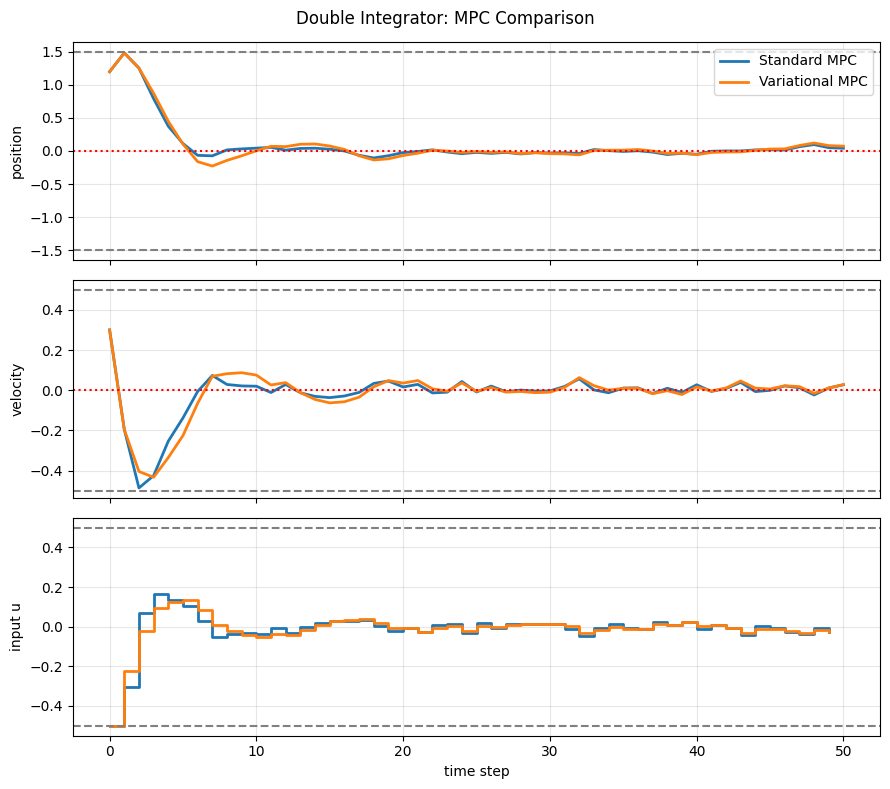

In [9]:
t  = np.arange(T_steps + 1)
tu = np.arange(T_steps)

fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)

labels  = ["Standard MPC", "Variational MPC"]
xs_list = [xs_std, xs_var]
us_list = [us_std, us_var]
colors  = ["tab:blue", "tab:orange"]

# Position
for xs, lbl, col in zip(xs_list, labels, colors):
    axes[0].plot(t, xs[:, 0], label=lbl, color=col, linewidth=2.0)
axes[0].axhline(0, color="red", linestyle=":", linewidth=1.5)
axes[0].axhline( di.p_max, color='gray', linestyle='--', linewidth=1.5)
axes[0].axhline(-di.p_max, color='gray', linestyle='--', linewidth=1.5)
axes[0].set_ylabel("position")
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Velocity
for xs, lbl, col in zip(xs_list, labels, colors):
    axes[1].plot(t, xs[:, 1], label=lbl, color=col, linewidth=2.0)
axes[1].axhline(0, color="red", linestyle=":", linewidth=1.5)
axes[1].axhline( di.v_max, color='gray', linestyle='--', linewidth=1.5)
axes[1].axhline(-di.v_max, color='gray', linestyle='--', linewidth=1.5)
axes[1].set_ylabel("velocity")
axes[1].grid(True, alpha=0.3)

# Control input
for us, lbl, col in zip(us_list, labels, colors):
    axes[2].step(tu, us[:, 0], where="post", label=lbl, color=col, linewidth=2.0)
axes[2].axhline( di.u_max, color="gray", linestyle="--", linewidth=1.5)
axes[2].axhline(-di.u_max, color="gray", linestyle="--", linewidth=1.5)
axes[2].set_ylabel("input u")
axes[2].set_xlabel("time step")
axes[2].grid(True, alpha=0.3)

fig.suptitle("Double Integrator: MPC Comparison")
plt.tight_layout()
plt.show()


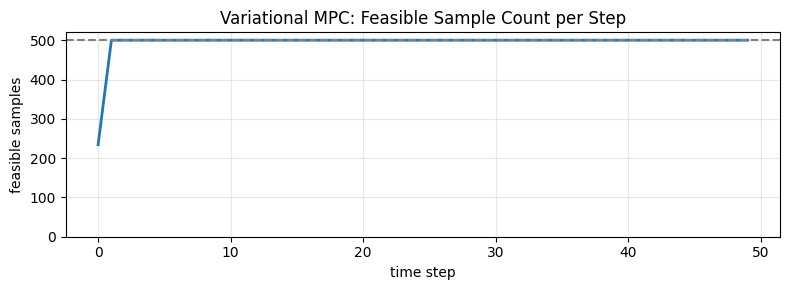

In [10]:
accept_series = np.array([d["accept_num"] for d in info_var])

plt.figure(figsize=(8, 3))
plt.plot(np.arange(T_steps), accept_series, linewidth=2.0)
plt.axhline(K_samples, color="gray", linestyle="--", linewidth=1.5)
plt.ylabel("feasible samples")
plt.xlabel("time step")
plt.ylim(0, K_samples + 20)
plt.title("Variational MPC: Feasible Sample Count per Step")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()